# Gender Pay Gap Analysis (MORG 2014)

## Introduction

> **Note:** This notebook is part of an assignment submission for a Data Analysis course at CEU.

This portfolio notebook studies the gender pay gap among Elementary and Middle School Teachers (occupation code 2310) in the MORG 2014 dataset.

I use `Python`, `pandas`, data visualization, and `statsmodels` OLS regressions with robust standard errors (`HC3`) to estimate both unconditional and education-conditional gender wage gaps.

## Data Loading & Cleaning

In this section, I load the raw file, filter the sample to teachers, and construct clean variables for analysis. The goal is to prepare a consistent regression-ready dataset.

In [16]:
# Import core libraries for data handling, plotting, and regression modeling
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Keep notebook output clean by suppressing non-critical warnings
warnings.filterwarnings("ignore")

# Optional style for cleaner plots in GitHub rendering
sns.set_theme(style="whitegrid")

# Ensure output directory exists for saving plots
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

I first load the dataset and quickly inspect it to confirm columns and data types look as expected before filtering.

In [17]:
# Load the MORG 2014 data
df_raw = pd.read_csv("../data/morg2014.csv")

# Quick structural check
print(df_raw.shape)
print(df_raw.head())

(317056, 96)
             hhid intmonth  hurespli minsamp                     hrlonglk  \
0   2600310997690  January       1.0   MIS 8  MIS 2-4 Or MIS 6-8 (link To   
1   2600310997690  January       1.0   MIS 8  MIS 2-4 Or MIS 6-8 (link To   
2   2600310997690  January       1.0   MIS 8  MIS 2-4 Or MIS 6-8 (link To   
3  41110310970391  January       1.0   MIS 8  MIS 2-4 Or MIS 6-8 (link To   
4  75680310997590  January       1.0   MIS 8  MIS 2-4 Or MIS 6-8 (link To   

   hrsample  hrhhid2  serial  hhnum state  ... ym_file   ym  ch02  ch35  \
0      9100    91001       1      1    63  ...     648  633     0     0   
1      9100    91001       1      1    63  ...     648  633     0     0   
2      9100    91001       1      1    63  ...     648  633     0     0   
3      9100    91001       1      1    63  ...     648  633     0     0   
4      9100    91001       1      1    63  ...     648  633     1     0   

   ch613  ch1417  ch05  ihigrdc  \
0      0       0     0     18.0   
1  

Next, I restrict the sample to Elementary and Middle School Teachers (`occ2012 == 2310`) and standardize column names used throughout the notebook.

In [18]:
# Keep only Elementary and Middle School Teachers (occupation code 2310)
target_occupation_code = 2310
teachers_df = df_raw.loc[df_raw["occ2012"] == target_occupation_code].copy()

print(teachers_df.shape)
print(teachers_df.head())

(4368, 96)
                hhid intmonth  hurespli minsamp                     hrlonglk  \
42   954001919079770  January       1.0   MIS 4  MIS 2-4 Or MIS 6-8 (link To   
54   981709270829007  January       1.0   MIS 4  MIS 2-4 Or MIS 6-8 (link To   
64     8097106057101  January       1.0   MIS 4  MIS 2-4 Or MIS 6-8 (link To   
115  310343067909068  January       1.0   MIS 4  MIS 2-4 Or MIS 6-8 (link To   
198  678011962039080  January       1.0   MIS 8  MIS 2-4 Or MIS 6-8 (link To   

     hrsample  hrhhid2  serial  hhnum state  ... ym_file   ym  ch02  ch35  \
42       9200    92001       1      1    63  ...     648  645     0     0   
54       9200    92001       1      1    63  ...     648  645     0     0   
64       9200    92001       1      1    63  ...     648  645     0     1   
115      9200    92001       1      1    63  ...     648  645     0     0   
198      9100    91001       1      1    63  ...     648  633     0     0   

     ch613  ch1417  ch05  ihigrdc  \
42      

In [19]:
# Rename key columns for readability in the analysis
teachers_df = teachers_df.rename(columns={"sex": "gender_code"}).copy()

print("Rows, columns:", teachers_df.shape)
print("Key columns present:", [c for c in ["earnwke", "uhours", "gender_code", "grade92", "occ2012"] if c in teachers_df.columns])

Rows, columns: (4368, 96)
Key columns present: ['earnwke', 'gender_code', 'grade92', 'occ2012']


I now construct the main analysis variables: hourly wage, log wage, a female indicator, and education groups with a clear reference category for regression interpretation.

In [20]:
# Identify hours-worked column available in this file version
hours_col = "uhourse" if "uhourse" in teachers_df.columns else "uhours"

# Keep valid wage/hour observations
teachers_df = teachers_df.loc[
    (teachers_df["earnwke"] > 0) & (teachers_df[hours_col] > 0)
].copy()

# Construct hourly wage and log hourly wage
teachers_df["hourly_wage"] = teachers_df["earnwke"] / teachers_df[hours_col]
teachers_df["ln_wage"] = np.log(teachers_df["hourly_wage"])

# Female indicator: CPS coding is 1=male, 2=female
teachers_df["female"] = np.where(teachers_df["gender_code"] == 2, 1, 0)

# Create education groups from grade92 coding
education_bins = [0, 40, 41, 43, 44, 99]
education_labels = [
    "Less than HS",
    "High School Grad",
    "Some College/Assoc",
    "College Grad",
    "Advanced Degree",
]
teachers_df["educ_group"] = pd.cut(
    teachers_df["grade92"],
    bins=education_bins,
    labels=education_labels,
    right=True,
    include_lowest=True,
    ordered=False,
)

# Set an explicit reference category for regressions
education_order = [
    "College Grad",
    "Less than HS",
    "High School Grad",
    "Some College/Assoc",
    "Advanced Degree",
]
teachers_df["educ_group"] = teachers_df["educ_group"].cat.set_categories(education_order)

# Drop missing values in regression variables
teachers_df = teachers_df.dropna(subset=["ln_wage", "female", "educ_group"]).copy()

print(f"Hours column used: {hours_col}")
print(f"Final analysis sample size (N): {len(teachers_df)}")
print("\nEducation group counts:\n", teachers_df["educ_group"].value_counts())

Hours column used: uhourse
Final analysis sample size (N): 3791

Education group counts:
 educ_group
College Grad          1777
Some College/Assoc    1687
Less than HS           200
Advanced Degree         96
High School Grad        31
Name: count, dtype: int64


I run a quick validation check to confirm the transformed variables look correct and match the intended coding.

In [21]:
# Validate key transformed variables
print("Verification sample (first 5 rows):")
columns_to_show = [
    "earnwke",
    hours_col,
    "gender_code",
    "grade92",
    "hourly_wage",
    "ln_wage",
    "female",
    "educ_group",
 ]
print(teachers_df[columns_to_show].head())

Verification sample (first 5 rows):
     earnwke  uhourse  gender_code  grade92  hourly_wage   ln_wage  female  \
42    826.92     40.0            2       44    20.673000  3.028829       1   
54     68.00      8.0            2       40     8.500000  2.140066       1   
115   673.07     45.0            2       43    14.957111  2.705187       1   
198  1000.00     56.0            2       44    17.857143  2.882404       1   
285   520.00     40.0            2       39    13.000000  2.564949       1   

             educ_group  
42         College Grad  
54         Less than HS  
115  Some College/Assoc  
198        College Grad  
285        Less than HS  


In [22]:
# Confirm gender mapping and counts
gender_counts = teachers_df["gender_code"].value_counts().sort_index()
gender_counts.index = gender_counts.index.map({1: "Male", 2: "Female"})
print("Gender counts in analysis sample:")
print(gender_counts)

Gender counts in analysis sample:
gender_code
Male       699
Female    3092
Name: count, dtype: int64


## Exploratory Data Analysis

I use a few concise plots to show the sample composition by gender and education before running regressions.

### Visualisations

#### Plot 1: Distribution of teachers by gender

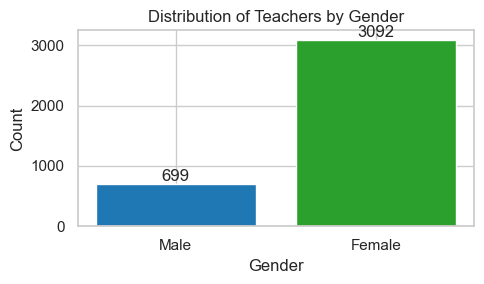

In [23]:
# Plot 1: Distribution of teachers by gender
gender_series = teachers_df["gender_code"].map({1: "Male", 2: "Female"})
gender_counts = gender_series.value_counts().reindex(["Male", "Female"])

plt.figure(figsize=(5, 3))
bars = plt.bar(gender_counts.index, gender_counts.values, color=["tab:blue", "tab:green"])
plt.title("Distribution of Teachers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height)}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("../outputs/gender_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**

The chart shows a much larger number of female teachers than male in this subsample.
This matches expectations for elementary/middle school teaching and clarifies the sample composition.

#### Plot 2: Education distribution by gender

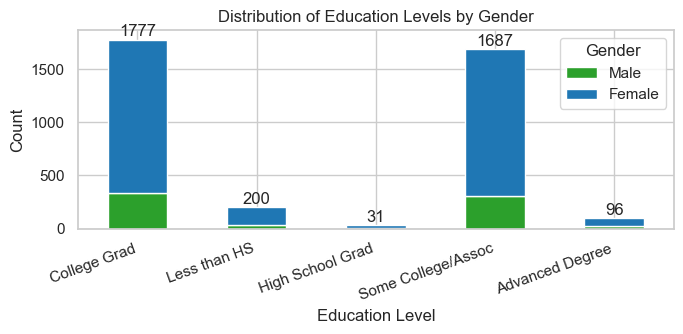

In [24]:
# Plot 2: Education distribution by gender (stacked bars)
edu_by_gender = pd.crosstab(teachers_df["educ_group"], teachers_df["female"])
edu_by_gender = edu_by_gender.rename(columns={0: "Male", 1: "Female"})

ax = edu_by_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 3.5),
    color=["tab:green", "tab:blue"],
)

plt.title("Distribution of Education Levels by Gender")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Gender")

for i, total in enumerate(edu_by_gender.sum(axis=1)):
    ax.text(i, total + 5, str(int(total)), ha="center", va="bottom")

plt.tight_layout()
plt.savefig("../outputs/education_by_gender_stacked.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**

Most teachers fall in the college graduate or some college/associate groups.
Female counts dominate each category, consistent with the overall gender distribution.
Smaller groups (e.g., high school or advanced degrees) imply less precision there.

## Regression Models

I estimate two OLS models with robust (`HC3`) standard errors:
- Model 1: unconditional wage gap (`ln_wage ~ female`)
- Model 2: education-conditional gap with interactions (`female * educ_group`)

### Naive regression

#### Table 1: Unconditional model

In [25]:
# Model 1: Unconditional gender gap
model1 = smf.ols(formula="ln_wage ~ female", data=teachers_df).fit(cov_type="HC3")
print(model1.summary())

# Convert log-point estimate into approximate percent gap
uncond_gap_pct = (np.exp(model1.params["female"]) - 1) * 100
print(f"\nEstimated unconditional gender pay gap: {uncond_gap_pct:.2f}%")

                            OLS Regression Results                            
Dep. Variable:                ln_wage   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     49.95
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.87e-12
Time:                        14:23:09   Log-Likelihood:                -3076.8
No. Observations:                3791   AIC:                             6158.
Df Residuals:                    3789   BIC:                             6170.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2445      0.019    168.495      0.0

**Interpretation**

Model 1 estimates a negative female coefficient, indicating lower average log wages for women.
The percent interpretation summarizes the unconditional gap before any controls.

#### Plot 3: Unconditional regression fit

This plot visualizes Model 1 by showing observed values and the fitted line between male (`0`) and female (`1`) groups.

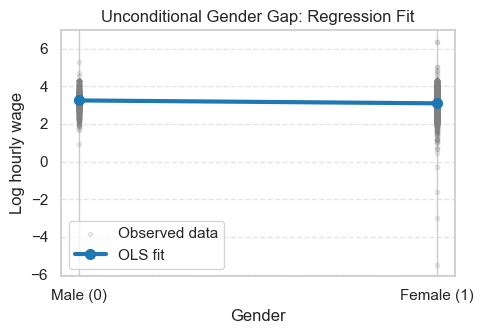

In [26]:
# Plot 3: Unconditional regression fit
plt.figure(figsize=(5, 3.5))
plt.scatter(
    teachers_df["female"],
    teachers_df["ln_wage"],
    alpha=0.15,
    color="gray",
    s=10,
    label="Observed data",
)

x_vals = np.array([0, 1])
y_vals = model1.params["Intercept"] + model1.params["female"] * x_vals
plt.plot(
    x_vals,
    y_vals,
    color="tab:blue",
    linewidth=3,
    marker="o",
    markersize=7,
    label="OLS fit",
)

plt.title("Unconditional Gender Gap: Regression Fit")
plt.xlabel("Gender")
plt.ylabel("Log hourly wage")
plt.xticks([0, 1], ["Male (0)", "Female (1)"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/unconditional_regression_fit.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**

The fitted line summarizes the mean log wage by gender and slopes downward from male to female.
Dispersion is wide, but the central tendency is lower for women in this sample.

#### Plot 4: Log wage density by gender

I also compare wage distributions by gender using kernel density curves to show how the gap appears across the distribution, not only at the mean.

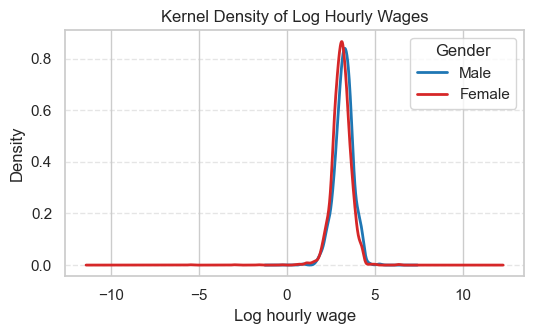

In [27]:
# Plot 4: Kernel density of log wages by gender
male_ln_wage = teachers_df.loc[teachers_df["female"] == 0, "ln_wage"].dropna()
female_ln_wage = teachers_df.loc[teachers_df["female"] == 1, "ln_wage"].dropna()

plt.figure(figsize=(5.5, 3.5))
male_ln_wage.plot(kind="density", color="tab:blue", linewidth=2, label="Male")
female_ln_wage.plot(kind="density", color="tab:red", linewidth=2, label="Female")

plt.title("Kernel Density of Log Hourly Wages")
plt.xlabel("Log hourly wage")
plt.ylabel("Density")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Gender")

plt.tight_layout()
plt.savefig("../outputs/log_wage_density_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**

The density curves largely overlap, but the female distribution is slightly shifted left.
This visual pattern aligns with the negative average gap from Model 1.

For Model 1, the female coefficient is negative and statistically significant, indicating that women in this sample earn less on average than men before controlling for education. The percentage interpretation uses $100\times(\exp(\beta)-1)$.

I now estimate Model 2 with interaction terms to test whether the gender gap changes across education groups (relative to College Graduates).

### Regression with education controls

#### Table 2: Education interactions model

In [28]:
# Model 2: Conditional gender gap by education
model2 = smf.ols(
    formula="ln_wage ~ female * C(educ_group, Treatment(reference='College Grad'))",
    data=teachers_df,
).fit(cov_type="HC3")

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                ln_wage   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     40.59
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           9.87e-70
Time:                        14:23:10   Log-Likelihood:                -2913.7
No. Observations:                3791   AIC:                             5847.
Df Residuals:                    3781   BIC:                             5910.
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

**Interpretation**

Education levels are strongly related to wages in this specification.
The female coefficient remains negative after controlling for education, while interactions suggest limited differences in gaps by education level.

#### Plot 5: Conditional gaps by education (bar)

This bar chart converts Model 2 coefficients into percentage gaps for each education group to make interpretation more intuitive.

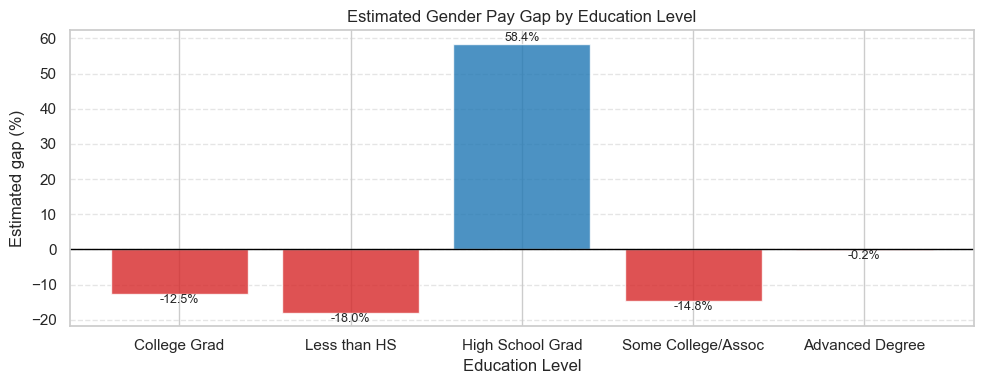

In [29]:
# Plot 5: Estimated conditional gender gap by education (percent)
base_gap = model2.params["female"]
interaction_terms = model2.params.filter(regex=r"female:C\(educ_group")

group_labels = ["College Grad"]
group_gaps_log = [base_gap]

for term in interaction_terms.index:
    # Keep label extraction readable from statsmodels naming
    clean_label = term.split("T.")[1].replace("]", "")
    group_labels.append(clean_label)
    group_gaps_log.append(base_gap + model2.params[term])

group_gaps_pct = (np.exp(group_gaps_log) - 1) * 100

plt.figure(figsize=(10, 4))
bar_colors = ["tab:red" if g < 0 else "tab:blue" for g in group_gaps_pct]
bars = plt.bar(group_labels, group_gaps_pct, color=bar_colors, alpha=0.8)

plt.title("Estimated Gender Pay Gap by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Estimated gap (%)")
plt.axhline(0, color="black", linewidth=1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{h:.1f}%",
        ha="center",
        va="bottom" if h >= 0 else "top",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("../outputs/conditional_gap_by_education_bar.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**

The bars translate the interaction effects into percent gaps by education group.
Most groups remain negative, with one small positive estimate, highlighting variability around the baseline.

#### Plot 6: Conditional gaps by education (scatter)

This companion scatter plot presents the same conditional estimates with a zero reference line for a quick visual check of penalties/premiums by group.

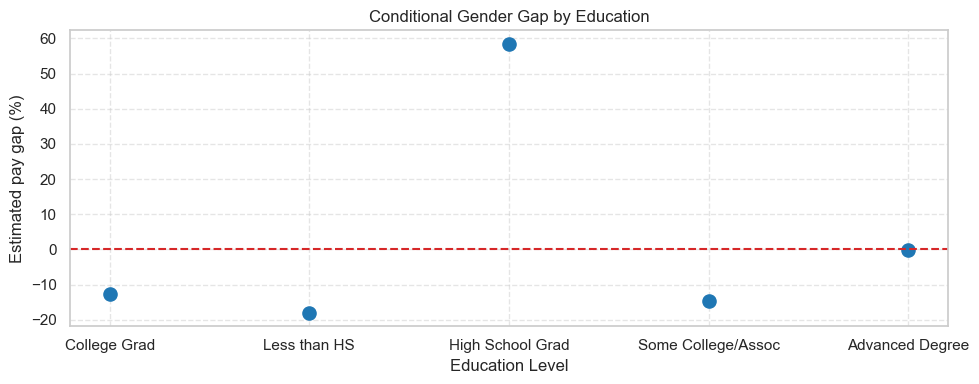

In [30]:
# Plot 6: Conditional gap by education (scatter view)
plt.figure(figsize=(10, 4))
plt.scatter(group_labels, group_gaps_pct, color="tab:blue", s=90)
plt.axhline(0, color="tab:red", linestyle="--", linewidth=1.5)
plt.title("Conditional Gender Gap by Education")
plt.xlabel("Education Level")
plt.ylabel("Estimated pay gap (%)")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/conditional_gap_by_education_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation**

The scatter view mirrors the bar chart, with points clustered around or below zero.
The zero line makes it easy to compare which education groups show penalties or near-parity.

## Results & Interpretation

The results point to a consistent gender pay gap among elementary and middle school teachers in the 2014 MORG sample. The unconditional model shows a negative female coefficient, and the fitted line and density plot align with a leftward shift in women’s log‑wage distribution.

When education controls are added, the gap narrows somewhat but remains negative. The interaction terms vary by education group, yet the overall pattern does not suggest large reversals. In short, education explains part of the difference, but a meaningful gap persists within this occupation.